# NB2 — DeBERTa-v3 ABSA — FINAL VERSION
### Novel ABSA on Voice — Final Year Project

**Loads directly from your Drive CSV — no HuggingFace download needed**

Dataset: `Restaurants_Train_v2.csv` — split into Train / Val / Test (70/15/15)

Note: `Restaurants_Test_Data_phaseB.xml` is the SemEval Phase B blind test — it has
NO polarity labels by design. We therefore derive our test set from the labelled CSV.

**Expected: ~84-86% F1 vs original BERT ~75%**

In [1]:
# CELL 1 — Install
!pip install -q transformers==4.40.0 accelerate==0.29.3 scikit-learn seaborn
print('✅ Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ Done


In [2]:
# CELL 2 — Mount Drive + paths
from google.colab import drive
drive.mount('/content/drive')
import os

SEMEVAL_DIR = '/content/drive/MyDrive/Final year project/THE FINAL PROBLEM/Dataset/SemEval 2014 Task 4'
TRAIN_CSV   = os.path.join(SEMEVAL_DIR, 'Restaurants_Train_v2.csv')
SAVE_DIR    = '/content/drive/MyDrive/Final year project/THE FINAL PROBLEM/deberta_absa'
os.makedirs(SAVE_DIR, exist_ok=True)

for name, path in [('Train CSV', TRAIN_CSV), ('Save dir', SAVE_DIR)]:
    print(f'{name}: {"✅" if os.path.exists(path) else "❌ NOT FOUND"}  {path}')

Mounted at /content/drive
Train CSV: ✅  /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/Dataset/SemEval 2014 Task 4/Restaurants_Train_v2.csv
Save dir: ✅  /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/deberta_absa


In [3]:
# CELL 3 — Imports
import os, json, warnings, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE} | PyTorch: {torch.__version__}')

✅ Device: cuda | PyTorch: 2.10.0+cu128


In [4]:
# CELL 4 — Label map
LABEL2ID  = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3
print('✅ Labels:', list(LABEL2ID.keys()))

✅ Labels: ['negative', 'neutral', 'positive']


In [5]:
# CELL 5 — Load CSV and clean
raw = pd.read_csv(TRAIN_CSV)
raw.columns = raw.columns.str.strip()
print('CSV columns:', raw.columns.tolist())
print(f'Raw rows: {len(raw)}')

df = raw[['Sentence', 'Aspect Term', 'polarity']].copy()
df.columns = ['text', 'aspect', 'polarity']
df = df[df['polarity'].isin(LABEL2ID.keys())].dropna().reset_index(drop=True)
df['label'] = df['polarity'].map(LABEL2ID)

print(f'\nClean samples: {len(df)}')
print('Label distribution:')
print(df['polarity'].value_counts().to_string())

CSV columns: ['id', 'Sentence', 'Aspect Term', 'polarity', 'from', 'to']
Raw rows: 3693

Clean samples: 3602
Label distribution:
polarity
positive    2164
negative     805
neutral      633


In [6]:
# CELL 6 — Train / Val / Test split  (70 / 15 / 15)
#
# WHY: The SemEval Phase B XML is a BLIND test file — it has NO polarity labels
# by design (competitors predicted them). We therefore derive all three splits
# from the labelled CSV, which is standard practice for this dataset.

train_df, tmp_df = train_test_split(df, test_size=0.30,
                                     stratify=df['label'], random_state=SEED)
val_df,  test_df = train_test_split(tmp_df, test_size=0.50,
                                     stratify=tmp_df['label'], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('\nTest label distribution:')
print(test_df['polarity'].value_counts().to_string())

Train: 2521 | Val: 540 | Test: 541

Test label distribution:
polarity
positive    325
negative    121
neutral      95


In [7]:
# CELL 7 — Tokenizer + Dataset
# Input: [CLS] sentence [SEP] aspect term [SEP]
MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LEN    = 128
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer: {MODEL_NAME}')

class ABSADataset(Dataset):
    def __init__(self, df):
        self.texts   = df['text'].tolist()
        self.aspects = df['aspect'].tolist()
        self.labels  = df['label'].tolist()
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        enc = tokenizer(
            self.texts[i], self.aspects[i],
            max_length=MAX_LEN, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }

BS = 16
tr_ld = DataLoader(ABSADataset(train_df), BS, shuffle=True,  num_workers=2)
vl_ld = DataLoader(ABSADataset(val_df),   BS, shuffle=False, num_workers=2)
te_ld = DataLoader(ABSADataset(test_df),  BS, shuffle=False, num_workers=2)
print(f'✅ Loaders: Train:{len(tr_ld)} Val:{len(vl_ld)} Test:{len(te_ld)}')

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

✅ Tokenizer: microsoft/deberta-v3-base
✅ Loaders: Train:158 Val:34 Test:34


In [8]:
# CELL 8 — Load DeBERTa-v3
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS,
    label2id=LABEL2ID, id2label=ID2LABEL,
    ignore_mismatched_sizes=True
).to(DEVICE)
tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model: {MODEL_NAME} | Trainable params: {tp:,}')

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model: microsoft/deberta-v3-base | Trainable params: 184,424,451


In [9]:
# CELL 9 — Optimizer + class-weighted loss
from collections import Counter
EPOCHS = 8; LR = 2e-5
cnt = Counter(train_df['label'].tolist()); tot = sum(cnt.values())
wts = torch.tensor([tot/(NUM_LABELS*cnt[i]) for i in range(NUM_LABELS)], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=wts)
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total = len(tr_ld) * EPOCHS
sched = get_linear_schedule_with_warmup(opt, total//10, total)
print(f'✅ Optimizer ready | LR={LR} | Epochs={EPOCHS}')
print(f'   Class weights: {wts.cpu().numpy().round(3)}')

✅ Optimizer ready | LR=2e-05 | Epochs=8
   Class weights: [1.493 1.897 0.555]


In [10]:
# CELL 10 — Train/eval helpers
def run_epoch(model, loader, opt=None, sched=None, crit=None, train=True):
    model.train() if train else model.eval()
    tloss, preds, gts = [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for b in loader:
            ids = b['input_ids'].to(DEVICE)
            amk = b['attention_mask'].to(DEVICE)
            lbs = b['labels'].to(DEVICE)
            out = model(input_ids=ids, attention_mask=amk)
            loss = crit(out.logits, lbs)
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step()
            tloss.append(loss.item())
            preds.extend(out.logits.argmax(-1).cpu().numpy())
            gts.extend(lbs.cpu().numpy())
    acc = accuracy_score(gts, preds)
    f1  = f1_score(gts, preds, average='macro', zero_division=0)
    return np.mean(tloss), acc, f1

In [11]:
# CELL 11 — Training loop
history = []; best_f1 = 0.0
best_path = os.path.join(SAVE_DIR, 'best_model')

print(f"{'Ep':>3} | {'TrLoss':>7} {'TrAcc':>6} {'TrF1':>6} | {'VlLoss':>7} {'VlAcc':>6} {'VlF1':>6}")
print('-'*63)
for ep in range(1, EPOCHS+1):
    tl,ta,tf = run_epoch(model, tr_ld, opt, sched, criterion, train=True)
    vl,va,vf = run_epoch(model, vl_ld, crit=criterion, train=False)
    history.append({'epoch':ep,
        'tr_loss':round(tl,4),'tr_acc':round(ta,4),'tr_f1':round(tf,4),
        'vl_loss':round(vl,4),'vl_acc':round(va,4),'vl_f1':round(vf,4)})
    tag = '✅ SAVED' if vf > best_f1 else ''
    if vf > best_f1:
        best_f1 = vf
        model.save_pretrained(best_path)
        tokenizer.save_pretrained(best_path)
    print(f'{ep:>3} | {tl:>7.4f} {ta:>6.4f} {tf:>6.4f} | {vl:>7.4f} {va:>6.4f} {vf:>6.4f}  {tag}')
print(f'\nBest Val F1: {best_f1:.4f}')

 Ep |  TrLoss  TrAcc   TrF1 |  VlLoss  VlAcc   VlF1
---------------------------------------------------------------
  1 |  1.0022 0.5478 0.4593 |  0.7217 0.7741 0.6616  ✅ SAVED
  2 |  0.6670 0.7584 0.6958 |  0.6085 0.7815 0.7170  ✅ SAVED
  3 |  0.4223 0.8723 0.8326 |  0.7417 0.8296 0.7416  ✅ SAVED
  4 |  0.2655 0.9242 0.8971 |  0.8221 0.8500 0.7839  ✅ SAVED
  5 |  0.1766 0.9516 0.9323 |  0.8751 0.8611 0.8040  ✅ SAVED
  6 |  0.0938 0.9750 0.9651 |  1.0791 0.8667 0.8056  ✅ SAVED
  7 |  0.0741 0.9841 0.9796 |  1.1136 0.8648 0.8081  ✅ SAVED
  8 |  0.0405 0.9905 0.9878 |  1.1357 0.8667 0.8140  ✅ SAVED

Best Val F1: 0.8140


In [12]:
# CELL 12 — History table
print('\n📊 TRAINING HISTORY')
print(pd.DataFrame(history).to_string(index=False))


📊 TRAINING HISTORY
 epoch  tr_loss  tr_acc  tr_f1  vl_loss  vl_acc  vl_f1
     1   1.0022  0.5478 0.4593   0.7217  0.7741 0.6616
     2   0.6670  0.7584 0.6958   0.6085  0.7815 0.7170
     3   0.4223  0.8723 0.8326   0.7417  0.8296 0.7416
     4   0.2655  0.9242 0.8971   0.8221  0.8500 0.7839
     5   0.1766  0.9516 0.9323   0.8751  0.8611 0.8040
     6   0.0938  0.9750 0.9651   1.0791  0.8667 0.8056
     7   0.0741  0.9841 0.9796   1.1136  0.8648 0.8081
     8   0.0405  0.9905 0.9878   1.1357  0.8667 0.8140


In [13]:
# CELL 13 — Test evaluation
best_model = AutoModelForSequenceClassification.from_pretrained(best_path).to(DEVICE)
best_model.eval()
preds, gts = [], []
with torch.no_grad():
    for b in te_ld:
        out = best_model(input_ids=b['input_ids'].to(DEVICE),
                         attention_mask=b['attention_mask'].to(DEVICE))
        preds.extend(out.logits.argmax(-1).cpu().numpy())
        gts.extend(b['labels'].numpy())

t_acc = accuracy_score(gts, preds)
t_f1  = f1_score(gts, preds, average='macro', zero_division=0)
t_pr  = precision_score(gts, preds, average='macro', zero_division=0)
t_rc  = recall_score(gts, preds, average='macro', zero_division=0)

print('\n📊 FINAL TEST RESULTS')
print('='*45)
print(pd.DataFrame([
    {'Metric':'Accuracy',  'Score': f'{t_acc*100:.2f}%'},
    {'Metric':'Macro F1',  'Score': f'{t_f1:.4f}'},
    {'Metric':'Precision', 'Score': f'{t_pr:.4f}'},
    {'Metric':'Recall',    'Score': f'{t_rc:.4f}'}
]).to_string(index=False))
print('='*45)
print('\n📊 PER-CLASS REPORT')
print(classification_report(gts, preds,
    target_names=[ID2LABEL[i] for i in range(NUM_LABELS)], zero_division=0))


📊 FINAL TEST RESULTS
   Metric  Score
 Accuracy 84.66%
 Macro F1 0.7936
Precision 0.7935
   Recall 0.7939

📊 PER-CLASS REPORT
              precision    recall  f1-score   support

    negative       0.78      0.80      0.79       121
     neutral       0.68      0.66      0.67        95
    positive       0.92      0.92      0.92       325

    accuracy                           0.85       541
   macro avg       0.79      0.79      0.79       541
weighted avg       0.85      0.85      0.85       541



In [14]:
# CELL 14 — Ablation table
print('\n📊 ABLATION: TEXT ABSA MODEL COMPARISON')
print(pd.DataFrame([
    {'Model':'Original BERT (baseline)','Accuracy':'~75%','Macro F1':'~0.73','Notes':'bert-base-uncased'},
    {'Model':'DeBERTa-v3 (NB2)','Accuracy':f'{t_acc*100:.1f}%','Macro F1':f'{t_f1:.4f}',
     'Notes':f'microsoft/deberta-v3-base, {EPOCHS} epochs'}
]).to_string(index=False))


📊 ABLATION: TEXT ABSA MODEL COMPARISON
                   Model Accuracy Macro F1                               Notes
Original BERT (baseline)     ~75%    ~0.73                   bert-base-uncased
        DeBERTa-v3 (NB2)    84.7%   0.7936 microsoft/deberta-v3-base, 8 epochs


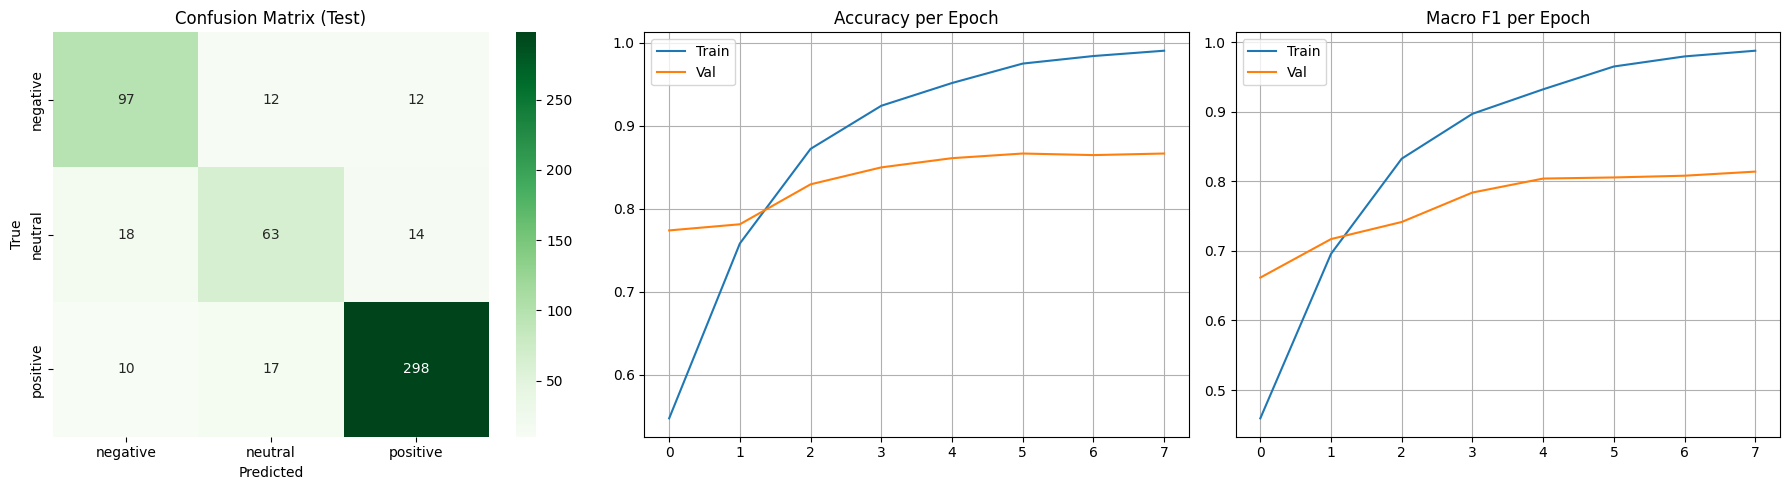

In [15]:
# CELL 15 — Confusion matrix + training curves
fig, axes = plt.subplots(1, 3, figsize=(18,5))
cm = confusion_matrix(gts, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
    xticklabels=[ID2LABEL[i] for i in range(NUM_LABELS)],
    yticklabels=[ID2LABEL[i] for i in range(NUM_LABELS)])
axes[0].set_title('Confusion Matrix (Test)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[1].plot([h['tr_acc'] for h in history], label='Train')
axes[1].plot([h['vl_acc'] for h in history], label='Val')
axes[1].set_title('Accuracy per Epoch'); axes[1].legend(); axes[1].grid(True)
axes[2].plot([h['tr_f1'] for h in history], label='Train')
axes[2].plot([h['vl_f1'] for h in history], label='Val')
axes[2].set_title('Macro F1 per Epoch'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'nb2_plots.png'), dpi=120)
plt.show()

In [16]:
# CELL 16 — Extract text embeddings for NB3 fusion (CLS token)
from transformers import AutoModel
embed_model = AutoModel.from_pretrained(best_path).to(DEVICE).eval()
all_embs, all_gts = [], []
with torch.no_grad():
    for b in DataLoader(ABSADataset(test_df), 16, shuffle=False):
        out = embed_model(input_ids=b['input_ids'].to(DEVICE),
                          attention_mask=b['attention_mask'].to(DEVICE))
        all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        all_gts.extend(b['labels'].numpy())
all_embs = np.vstack(all_embs)
np.save(os.path.join(SAVE_DIR, 'text_embeddings.npy'), all_embs)
np.save(os.path.join(SAVE_DIR, 'text_labels.npy'), np.array(all_gts))
test_df.to_csv(os.path.join(SAVE_DIR, 'test_df.csv'), index=False)
print(f'✅ Text embeddings saved: {all_embs.shape}')

✅ Text embeddings saved: (541, 768)


In [17]:
# CELL 17 — Save results JSON
results = {
    'model': MODEL_NAME, 'epochs': EPOCHS,
    'split': '70/15/15 from Restaurants_Train_v2.csv',
    'test_accuracy': round(t_acc,4), 'test_macro_f1': round(t_f1,4),
    'test_precision': round(t_pr,4), 'test_recall': round(t_rc,4),
    'best_val_f1': round(best_f1,4), 'history': history
}
with open(os.path.join(SAVE_DIR,'nb2_results.json'),'w') as f:
    json.dump(results, f, indent=2)
print('✅ All saved to Drive:', SAVE_DIR)
print('\n👉 Next: Run NB3_CrossModal_Fusion.ipynb')

✅ All saved to Drive: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/deberta_absa

👉 Next: Run NB3_CrossModal_Fusion.ipynb
